##### Mall Customer Segmentation using Clustering and PCA Assignment

##### Name: Alyssa Iapalucci
##### Assignment 9: Unsupervised Learning
##### Google Colab Link: https://colab.research.google.com/drive/1qXJS5Afqo7stLKmEvKvNMaeYPXzgeBBz?usp=sharing
##### GitHub Link: https://github.com/alyssaiapalucci4/lesson9-AI-mall-customer-clustering/tree/main

In [1]:
# SECTION 1: IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

import scipy.cluster.hierarchy as sch

In [2]:
# SECTION 2: LOAD DATASET

df = pd.read_csv("Mall_Customers.csv")

print("Dataset Loaded Successfully")
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

Dataset Loaded Successfully

First 5 Rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape:
(200, 5)


In [3]:
# SECTION 3: DATA EXPLORATION

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nChecking for Missing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())


Column Names:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Checking for Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.00

##### The dataset contains 200 customer records with demographic and spending information. No missing values were found.

In [4]:
# SECTION 4: DATA PREPROCESSING

# Remove CustomerID because it does not help clustering
df = df.drop("CustomerID", axis=1)

# Convert Gender into numerical format
df = pd.get_dummies(df, columns=["Gender"], drop_first=True)

print("Dataset after encoding:")
print(df.head())

Dataset after encoding:
   Age  Annual Income (k$)  Spending Score (1-100)  Gender_Male
0   19                  15                      39         True
1   21                  15                      81         True
2   20                  16                       6        False
3   23                  16                      77        False
4   31                  17                      40        False


In [5]:
# SECTION 5: FEATURE SCALING

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

print("Data scaled successfully")

Data scaled successfully


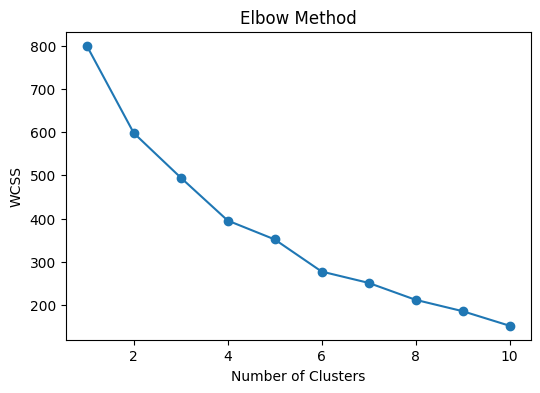

In [6]:
# SECTION 6: K-MEANS ELBOW METHOD

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

##### Based on the elbow graph, the optimal number of clusters appears to be 5.

In [7]:
# SECTION 7: APPLY K-MEANS

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)

kmeans_score = silhouette_score(scaled_data, kmeans_labels)

print("K-Means Silhouette Score:", kmeans_score)

K-Means Silhouette Score: 0.2719102346618833


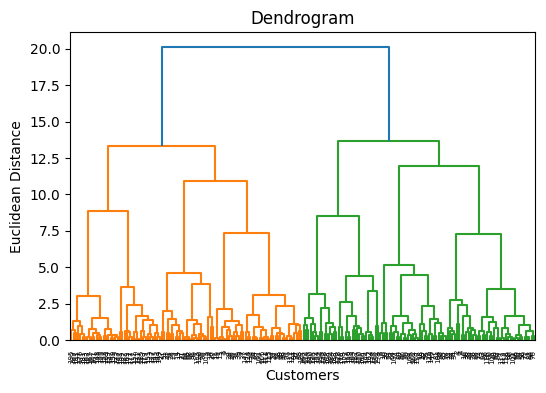

In [8]:
# SECTION 8: HIERARCHICAL CLUSTERING

plt.figure(figsize=(6,4))
sch.dendrogram(sch.linkage(scaled_data, method='ward'))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

In [9]:
# SECTION 9: APPLY HIERARCHICAL CLUSTERING

hc = AgglomerativeClustering(n_clusters=5)
hc_labels = hc.fit_predict(scaled_data)

hc_score = silhouette_score(scaled_data, hc_labels)

print("Hierarchical Clustering Silhouette Score:", hc_score)

Hierarchical Clustering Silhouette Score: 0.28699413201651747


In [10]:
# SECTION 10: PCA DIMENSIONALITY REDUCTION

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.33690046 0.26230645]


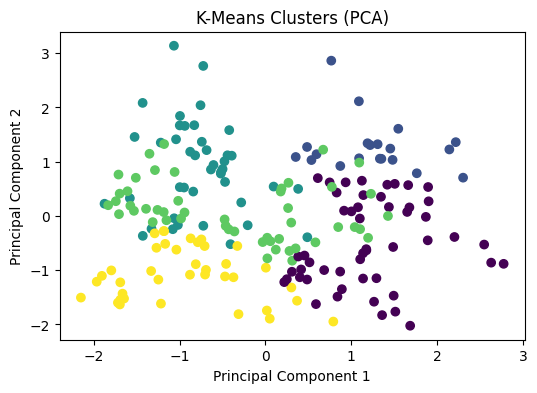

In [11]:
# SECTION 11: PCA VISUALIZATION (K-MEANS)

plt.figure(figsize=(6,4))
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=kmeans_labels
)

plt.title("K-Means Clusters (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

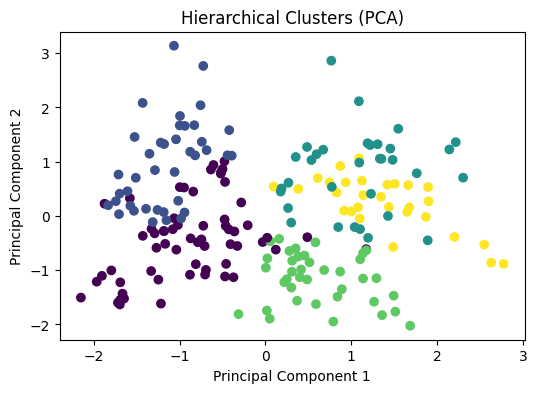

In [12]:
# SECTION 12: PCA VISUALIZATION (HIERARCHICAL)

plt.figure(figsize=(6,4))
plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=hc_labels
)

plt.title("Hierarchical Clusters (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

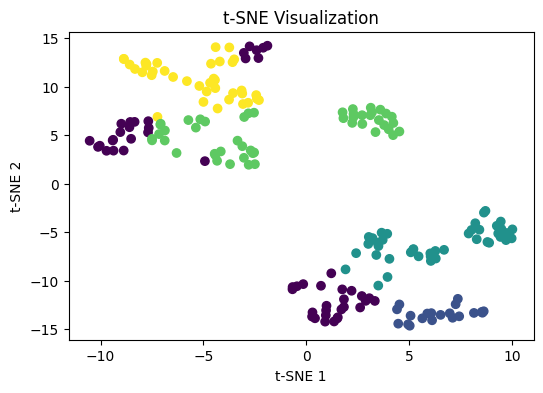

In [13]:
# SECTION 13: T-SNE VISUALIZATION

tsne = TSNE(n_components=2, random_state=42)
tsne_data = tsne.fit_transform(scaled_data)

plt.figure(figsize=(6,4))
plt.scatter(
    tsne_data[:,0],
    tsne_data[:,1],
    c=kmeans_labels
)

plt.title("t-SNE Visualization")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

In [14]:
# SECTION 14: MODEL EVALUATION

print("K-Means Silhouette Score:", kmeans_score)
print("Hierarchical Silhouette Score:", hc_score)

if kmeans_score > hc_score:
    print("K-Means performed better.")
else:
    print("Hierarchical Clustering performed better.")

K-Means Silhouette Score: 0.2719102346618833
Hierarchical Silhouette Score: 0.28699413201651747
Hierarchical Clustering performed better.


##### Section 15: Interpretation

K-Means and Hierarchical clustering were applied successfully.
The silhouette score was used to compare both methods.
PCA reduced the data into two dimensions and revealed visible cluster patterns.
t-SNE provided additional visualization for better understanding of customer segmentation.

##### Section 16: Deployment Strategy

his model could be deployed in a retail environment to segment customers for personalized marketing campaigns.

Examples:
- High spenders can receive premium promotions.
- Low spenders can receive discount offers.

Potential challenges:
- Large datasets may increase processing time.
- Customer behavior changes over time.
- Real-time segmentation may require optimized infrastructure.

##### Section 17: Monitoring Strategy

To monitor the model:
- Track changes in customer spending behavior.
- Monitor silhouette score after retraining.
- Detect data drift monthly.
- Retrain the clustering model when patterns change significantly.